In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [3]:
########################## CARGA DESDE ARCHIVO LOCAL ##########################
# Cargar el archivo local
data = pd.read_csv("dataset_penguins.csv")
# Ver las primeras filas
display(data.head())

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


Conocer (e investigar) la función de;  
Funcion de probabilidad de masas (PMF)  
Funcion de probabilidad acumulada  (CDF)  
Funcion de probabilidad de densidad (PDF)  
Sirve para modelar la incertidumbre de forma matemática, calcular probabilidades de eventos y tomar decisiones basadas en datos (riesgo, predicción, control de calidad, inferencia estadística)  
  
Ej con la base de datos clásica de los pingüinos (Palmer Penguins)  
PMF → especie, isla, sexo  
PDF → masa corporal, longitud del pico  
CDF → percentiles de peso, mediana, rangos, conteo de pingüinos por año

| Función | Variable | Da probabilidad directa | Gráfica típica  |
| ------- | -------- | ----------------------- | --------------- |
| PMF     | Discreta | Sí                      | Barras          |
| PDF     | Continua | No (solo áreas)         | Curva           |
| CDF     | Ambas    | Sí (acumulada)          | Curva creciente |
** La forma de la variable (discreta o continua) determina qué función usamos.
  
  
🔹 PMF – Probability Mass Function  
Para variables discretas (categorías, conteos).  
Por tanto, no es solo para números discretos, también aplica a variables categóricas.  
Por ejemplo, la variable 'species' es una variable categórica, y tambien una variable aleatoria discreta.  
-Da la probabilidad exacta de cada valor.  
Es básicamente frecuencia relativa / porcentaje.  
Se ve como barras.  
Ej: P(especie = Adelie)  
  
  
  
🔹 PDF – Probability Density Function  
Para variables continuas (peso, altura).  
No da probabilidades directas en un punto.  
La probabilidad es el área bajo la curva entre dos valores.  
Se ve como curva suave (normal, KDE).  
Ej: densidad del peso corporal  
  
🔹 CDF – Cumulative Distribution Function  
Para discretas y continuas.  
Da la probabilidad acumulada hasta un valor.  
Siempre va de 0 a 1 y nunca decrece.  
Permite leer mediana, percentiles.  
Ej: P(peso ≤ 4000 g)  

In [4]:
####################DEMOSTRACIONES#####################

PMF de la especie de pingüinos: (Tabla de probabilidades)


species
Adelie       0.441860
Gentoo       0.360465
Chinstrap    0.197674
Name: proportion, dtype: float64

<class 'pandas.core.series.Series'>


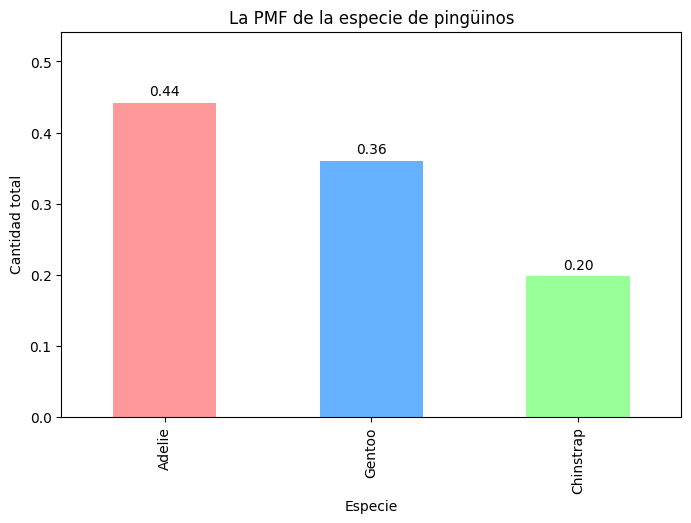

--------------------------------------------------
NOTA: la suma de probabilidades es igual a: 1.0
NOTA: la suma de conteos es igual al total de datos: reg en data 344 == suma de conteos 344
--------------------------------------------------


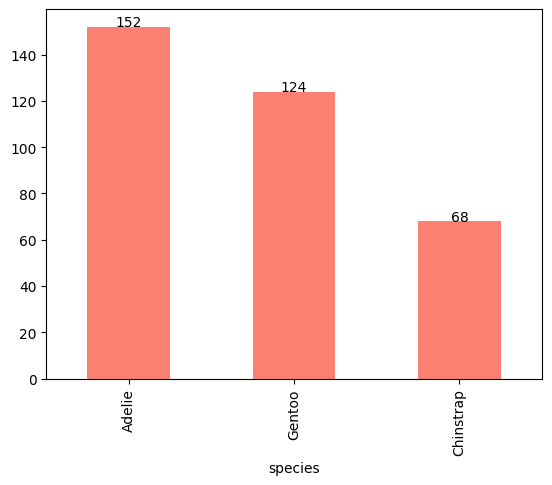

In [5]:
####################### PMF de species

# PMF – Probability Mass Function
# EJEMPLO PMF: frecuencias relativas de la variable categórica 'species' (Pandas + Matplotlib)
pmf_species = data['species'].value_counts(normalize=True)
# pmf_species  representación de la PMF, es el insumo para calcular probabilidades exactas y hacer inferencias estadísticas (distribución categórica)
# pmf_species es una Serie de Pandas donde el índice son las especies y los valores son las probabilidades
# pmf_ significa "probability mass function" (función de masa de probabilidad) (asigna una probabilidad a cada valor posible de una variable aleatoria discreta)
print("PMF de la especie de pingüinos: (Tabla de probabilidades)")
display(pmf_species)
print(type(pmf_species)) # es una Serie de Pandas
plt.figure(figsize=(8, 5)) # debe ir al principio de todo el bloque de código. Si lo pones al final, creará una ventana nueva en blanco
# colocar el valor arriba de cada barra
for i, v in enumerate(pmf_species):
    plt.text(i, v + 0.01, f"{v:.2f}", ha='center')
# dar mas espacion arriba:
plt.ylim(0, pmf_species.max() + 0.1)    
# pmf_species.plot(kind='bar')
pmf_species.plot(kind='bar', color=['#FF9999', '#66B2FF', '#99FF99'])
plt.title("PMF de la especie de pingüinos")
plt.xlabel("Especie")
plt.ylabel("Probabilidad")
plt.title("La PMF de la especie de pingüinos") # PMF quiere decir "Función de Masa de Probabilidad"
plt.ylabel("Cantidad total") # Cambiamos etiqueta Y
plt.show()

# --- 
# La suma de todas las probabilidades debe ser 1
print("-----"*10)
print("NOTA: la suma de probabilidades es igual a:", pmf_species.sum())
# La suma de los conteos debe ser el total de datos
total_count = data.shape[0]
print(f"NOTA: la suma de conteos es igual al total de datos: reg en data {total_count} == suma de conteos {data['species'].value_counts().sum()}")
print("-----"*10)
# --- CAMBIO:
# Gráfico de barras contando cuántas veces aparece cada especie ---
# Cambia normalize=True a False (o quítalo, por defecto es False) 
counts_species = data['species'].value_counts(normalize=False) 
# Colocar el valor arriba de cada barra
for i, v in enumerate(counts_species):
    plt.text(i, v + 0.1, str(v), ha='center') # v ahora es un entero, no necesita :.2f
counts_species.plot(kind='bar', color='salmon') # Agregamos color aquí
plt.show()

/tmp/ipykernel_57984/917402725.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='species', data=data, palette='Set2', order=data['species'].value_counts().index)


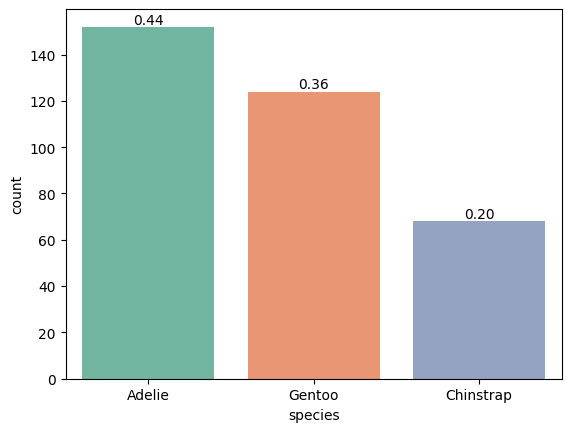

In [6]:
# EXTRA: Gráfico de barras contando cuántas veces aparece cada especie (countplot de Seaborn, de Probabilidad (PMF) a Conteos)

# x='species': La columna que se contará
# data=data: El DataFrame donde están los datos
# palette='Set2': El esquema de colores (tonos pasteles/suaves)
# order=...: Ordena las barras de mayor a menor frecuencia
sns.countplot(x='species', data=data, palette='Set2', order=data['species'].value_counts().index)

# Calcula el número total de filas en el dataset para sacar porcentajes
total_count = len(data)

# Bucle que recorre cada barra (llamadas 'patches' en Matplotlib) para poner texto encima
for p in plt.gca().patches:
    height = p.get_height()  # Obtiene la altura de la barra (el conteo)
    
    # Añade el texto (anotación de la proporción) sobre la barra
    # f"{height/total_count:.2f}": Calcula la proporción y la formatea a 2 decimales
    # (p.get_x() + p.get_width() / 2., height): Posiciona el texto en el centro horizontal y arriba de la barra
    # ha='center', va='bottom': Alineación horizontal centrada y vertical hacia abajo
    plt.gca().annotate(f"{height/total_count:.2f}", (p.get_x() + p.get_width() / 2., height),
                       ha='center', va='bottom')
plt.show()

nota: No puedes usar value_counts(normalize=True) con variables continuas pues: la Masa de Probabilidad (PMF) es para categorías discretas, mientras que para variables continuas como el peso (body_mass_g), se utiliza la Densidad de Probabilidad (PDF).Si intentas usar value_counts() en el peso, obtendrás una lista gigante de valores que casi no se repiten, porque es raro que dos pingüinos pesen exactamente 3800.25g, y todas las probabilidades serían casi 0. 

In [7]:
# EJEMPLO de pregunta: ¿Cuál es la probabilidad de que un pingüino sea de la especie 'Adelie'?
# Metodo: búsqueda de probabilidad puntual (o lectura de diccionario).

# Función de masa de probabilidad (PMF) para una variable aleatoria discreta.
def pmf(pmf_dict, value): # Función para calcular la PMF para un valor específico
    return pmf_dict.get(value, 0)
    """
    Calcula la función de masa de probabilidad (PMF) para una variable aleatoria discreta.

    Parámetros:
    probabilities (dict): Un diccionario donde las claves son los valores posibles de la variable aleatoria
                          y los valores son las probabilidades asociadas a esos valores.
    value: El valor para el cual se desea calcular la PMF.

    Retorna:
    float: La probabilidad asociada al valor 'value'. Si value no está en las claves del diccionario, retorna 0.
    """
# presentar la probabilidad de un valor específico

value = 'Adelie'  ##### Ya se conoce el valor que se quiere consultar su probabilidad. !!!!! 
prob = pmf(pmf_species.to_dict(), value)
print(f"La probabilidad de que un pingüino sea de la especie '{value}' es: {prob:.2f}")
# La probabilidad de que un pingüino sea de la especie 'Adelie' es: 0.44

# NOTA: No está buscando el "ganador" (moda), sino simplemente preguntando: "En mi tabla de probabilidades, ¿qué número le corresponde a esta especie específica?".

La probabilidad de que un pingüino sea de la especie 'Adelie' es: 0.44


In [8]:
# USO DE LA MODA EN PANDAS para datos categóricos, para encontrar el valor más frecuente (Función de masa de probabilidad máxima)
# NOTA: la Moda no es parte de la PMF, sino una medida de tendencia central que se extrae de ella (es una consecuencia).
# Si miras la PMF, la moda es simplemente el valor que tiene la "masa" (probabilidad) más alta.
# ---- 
moda_especie_ = data['species'].mode()
# mode() devuelve una Serie con el/los valores más frecuentes
# en caso de empate, devuelve todos los valores empatados (por tanto importante para validar si hay empate o no)
print(moda_especie_)
# NOTA EXTRA: df['col'].fillna(df['col'].mode()[0]) # es una linea común para rellenar valores nulos con la moda (lo que se llama Inputación)
print("----")
# Se desee ahora encontrar la especie más probable (moda) usando la PMF calculada anteriormente
# ¿Cuál es la especie más probable de observar?
moda_species = pmf_species.idxmax() 
# idxmax() devuelve el índice (especie) del valor máximo en la Serie
# Se aplica a una tabla de frecuencias ya resumida.
# retorna un string (valor unico)
# nota: devuelve la primera que encuentre, ignorando el empate. (OJO)
print(f"{moda_species} es la especie más probable. Tipo de objeto: {type(moda_species)} ")
prob_moda = pmf_species.max()
# max() devuelve el valor máximo en la Serie
print(f"La especie más probable es {moda_species} con una probabilidad de {prob_moda:.2%}")
# La especie más probable es Adelie con una probabilidad de 44.19%

#La moda es simplemente el valor con máxima probabilidad en la PMF




0    Adelie
Name: species, dtype: object
----
Adelie es la especie más probable. Tipo de objeto: <class 'str'> 
La especie más probable es Adelie con una probabilidad de 44.19%


### Las Distribución categórica”

Es el nombre conceptual para: cómo se reparten las observaciones entre las categorías de una variable categórica Y se describe usando la PMF. (La forma completa de la PMF)
Una distribución categórica responde preguntas como:
> ¿Cómo se reparten todas las categorías?
> ¿Qué categorías existen?
> ¿Qué tan representativa es cada una?
> ¿Hay una categoría dominante?
> ¿Están balanceadas o desbalanceadas?
> ¿Hay categorías raras o casi vacías?

La distribución categórica describe cómo se reparten las observaciones entre las categorías de una variable. Se analiza a través de la PMF empírica, sus proporciones y su forma visual, permitiendo identificar dominancia, balance o rareza de categorías.  (Es la interpretación estructurada de una PMF sobre categorías.)


~~~
La distribución categórica NO es el gráfico (de Distribución), NO es la Serie (tabla de probabilidades) es la  interpretación sobre ellos (la forma en que las probabilidades se reparten entre las categorías)
~~~

### **La distribución categórica se describe así:**
> Proporciones / porcentajes  
¿Qué porcentaje del total pertenece a cada categoría?  
Adelie: 44%  
Gentoo: 36%  
Chinstrap: 20%.  
> Balance / desbalance de la distribución   
¿Las categorías están equilibradas o una domina claramente?  
No es uniforme (no todas ≈ 33%)    
¿puedo usar esta variable sin ponderar?  
> Categoría dominante y categorías minoritarias  
¿Hay categorías mayoritarias o minoritarias claras?  
Adelie dominante  
Chinstrap minoritariaTampoco es extrema (no hay 90% vs 10%)  
> Uniformidad vs concentración  
¿La probabilidad está repartida de forma pareja o concentrada en pocas categorías?  
Concentración moderada en Adelie  
No es uniforme  
No es altamente concentrada  
> Coherencia / validación de datos  
¿Esta distribución tiene sentido con lo que espero del fenómeno?  
¿Es razonable que haya menos Chinstrap?  
¿Hay categorías con probabilidad cero inesperadas?    
¿Faltan especies?  
  
  
> Conclucion:  
La categoría Adelie es la más probable (moda) (Adelie es dominante)  
Por tanto: La distribución está dominada por Adelie  
Gentoo tiene una presencia relevante pero menor (es común pero secundaria)  
Chinstrap es minoritaria  
La distribución está moderadamente desbalanceada  
No hay categorías raras (todas tienen peso), ni extremadamente dominantes  
La distribución es moderadamente desbalanceada.  

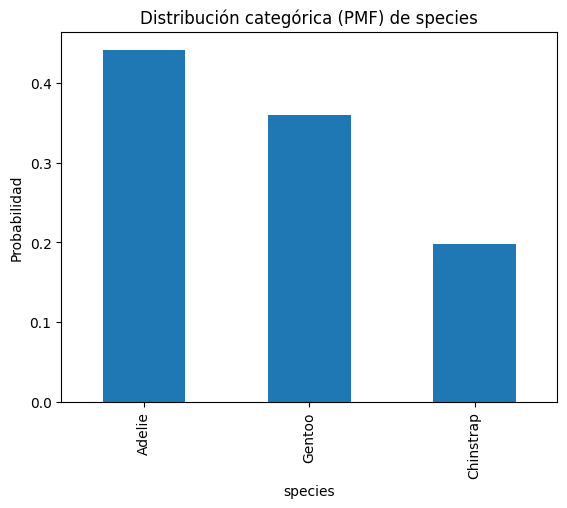

In [9]:
pmf_species = data['species'].value_counts(normalize=True)
pmf_species.plot(kind='bar')
plt.ylabel("Probabilidad")
plt.title("Distribución categórica (PMF) de species")
plt.show()

### Un nivel más allá: PMF deja de ser “una tablita” y se vuelve análisis
PMF condicional es una herramienta poderosa para profundizar en el análisis de variables categóricas. Al segmentar la PMF por otra variable, podemos descubrir patrones y relaciones ocultas en los datos. Por ejemplo, al analizar la PMF de 'species' condicionada por 'island', podemos identificar qué especies son más comunes en cada isla, revelando así interacciones ecológicas y preferencias de hábitat. Esta técnica nos permite ir más allá de la simple distribución global y entender mejor la dinámica interna de nuestras variables categóricas.
> P(species∣island) comparacion de distribuciones categóricas entre grupos.

Qué significa “comparar distribuciones categóricas” No estás calculando un nuevo estadístico, sino respondiendo preguntas como:
¿Cómo cambia la probabilidad de cada categoría cuando condiciono por otro grupo?
¿Cómo cambia la distribución categórica entre grupos?

Ejemplos de preguntas que se pueden responder con PMF condicional:  
¿La especie más común es la misma en todas las islas?  
¿El reparto de especies es igual entre machos y hembras?  
¿Hay cambios en el tiempo (si existiera year)?  
¿Alguna isla tiene una especie rara o dominante diferente?  
¿Cómo varía la diversidad de especies entre islas?  
¿Existen interacciones entre variables categóricas (isla y sexo) que afectan la distribución de especies?  
¿La especie dominante es la misma en todos los grupos?  
¿Existen grupos donde una categoría es claramente mayoritaria?  
¿La distribución es más balanceada en algunos grupos que en otros?  
¿Aparecen categorías ausentes (probabilidad ≈ 0) en ciertos grupos?  
¿El fenómeno es homogéneo o depende del grupo?


In [10]:
####################### PMF condicional P(species | island)
# Comparación entre distribuciones categóricas 🔥
# Ejemplos: # species por island
'''
DATOS: 
La variable categórica principal:
- species
Condicionada por otra variable:
- island
Análisis:
P(species | island)
# Probabilidad Condicional: la probabilidad de observar una especie dado que estamos en una isla específica ($P(\text{especie} | \text{isla})$).
'''
# Preguntas
# ¿Cómo varía la distribución de species según la isla?
# ¿Hay especies dominantes en ciertas islas?
# ¿Existen especies raras en alguna isla específica?
# La distribución categórica depende de la isla?

island_species_counts = data.groupby('island')['species'].value_counts(normalize=True).unstack()
print("Tabla de distribución de probabilidad condicional (de species por island) P(species∣island)"   )
print("Obtenida mediante frecuencias relativas / PMF empírica)"   )
display(island_species_counts)
print(type(island_species_counts)) # <class 'pandas.core.frame.DataFrame'>
# Es una distribución de probabilidad
# Es condicional
# Variable aleatoria: species
# Condición: island
# Esta tabla se obtiene a partir de una tabla de contingencia normalizada por filas, por lo que cada fila suma 1.
# Representa una PMF empírica de la variable categórica species condicionada a la isla.
# Los valores indican frecuencias relativas (probabilidades) y permiten analizar cómo cambia la distribución categórica entre islas.
# VER BLOG
'''
Tabla de contingencia normalizada // PMF de species condicionada por island (Distribución categórica P(species | island)):
Tabla Frecuencia Relativa o, más técnicamente, Distribución de Probabilidad Condicional P(species | island)):
species	Adelie	Chinstrap	Gentoo
island			
Biscoe	0.261905	NaN	0.738095
Dream	0.451613	0.548387	NaN
Torgersen	1.000000	NaN	NaN
'''
# El echo que alla NaN indica que no hay datos para esa combinación isla-especie



# island_species_counts.plot(kind='bar', stacked=True, colormap='viridis')
# # stacked = apila las barras para ver la composición total por isla
# # colormap = 


# plt.title("Distribución categórica de species por island (PMF condicionada)")
# plt.ylabel("Probabilidad")
# plt.legend(title='Species')
# plt.show()
''' ---- '''

Tabla de distribución de probabilidad condicional (de species por island) P(species∣island)
Obtenida mediante frecuencias relativas / PMF empírica)


species,Adelie,Chinstrap,Gentoo
island,,,
Biscoe,0.261905,NaN,0.738095
Dream,0.451613,0.548387,NaN
Torgersen,1.000000,NaN,NaN


<class 'pandas.core.frame.DataFrame'>


' ---- '

### Análisis de las preguntas (Basado en la tabla)  
1. ¿Cómo varía la distribución de species según la isla?  
* La variación es total. Cada isla tiene una "firma" de especies única. Por ejemplo,  
  La isla Torgersen es mono-especie (100% Adelie), mientras que las otras dos están divididas entre dos especies diferentes.
2. ¿Hay especies dominantes en ciertas islas?
* Sí.
    En Biscoe, la especie dominante es Gentoo.  
    En Dream, hay una dominancia ligera de Chinstrap.
    En Torgersen, la dominante absoluta es Adelie ().
3. ¿Existen especies ausentes en algunas islas?
*  Se interpreta como presencia nula o muy baja, los NaN son la clave:
    Gentoo es "inexistente" en Dream y Torgersen.
    Chinstrap es inexistente en Biscoe y Torgersen.
4. ¿La distribución categórica depende de la isla?
* Sí. En estadística, diríamos que existe una dependencia entre las variables `island` y `species`.
    Por tanto, si conocer la isla te ayuda a predecir la especie con mayor seguridad que al azar, entonces hay dependencia. (comprobar estaditicamente con un test de independencia como Chi-cuadrado)

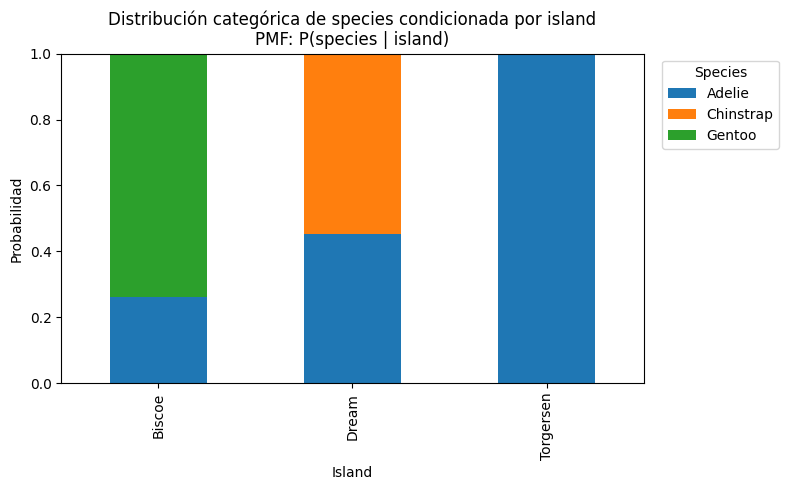

In [11]:
# Gráfico para detectar patrones visuales rápidos (comunicación)

# Reemplazamos NaN por 0 (especies ausentes - RECOMENDABLE)
pmf_species_island = island_species_counts.fillna(0)

# Crear figura
fig, ax = plt.subplots(figsize=(8, 5))

# Gráfico de barras apiladas
pmf_species_island.plot(
    kind='bar',
    stacked=True,
    ax=ax
)

# Etiquetas y título técnico
ax.set_title(
    "Distribución categórica de species condicionada por island\nPMF: P(species | island)",
    fontsize=12
)
ax.set_xlabel("Island")
ax.set_ylabel("Probabilidad")

# Asegurar escala correcta en Y
ax.set_ylim(0, 1)

# Leyenda fuera del gráfico (para que no estorbe)
ax.legend(
    title="Species",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

# Ajuste visual
plt.tight_layout()

plt.show()


❓ ¿Cómo varía la distribución de species según la isla?  
👉 Cada isla tiene una composición distinta de especies.  
❓ ¿Hay especies dominantes en ciertas islas?  
👉 Sí,
Torgersen → 100% Adelie (dominancia total)  
Biscoe → Gentoo dominante  
Dream → Adelie y Chinstrap más balanceadas  
❓ ¿Existen especies raras en alguna isla?  
👉 Sí:  
Gentoo no aparece en Dream ni Torgersen  
Chinstrap no aparece en Biscoe ni Torgersen  
❓ ¿La distribución categórica depende de la isla?  
👉 Sí, claramente  
Las PMF cambian según la isla  
→ species no es independiente de island  
(sin hacer aún pruebas estadísticas, esto es EDA puro)

POR TANTO:  
La distribución categórica de especies varía significativamente entre islas, indicando una fuerte dependencia entre la variable species y la variable island.

###  confirmación estadística (Chi-cuadrado)

Hipótesis nula (H₀):
La distribución de species NO cambia según island (species e island son independientes) (NO hay dependencia)
Hipótesis alternativa (H₁):
La distribución de species SÍ cambia según island (hay dependencia)

H₀ se rechaza si hay evidencia suficiente de que las PMF condicionales son diferentes entre islas.
H₀ por lo general se asume cierta hasta que se demuestre lo contrario (no hay dependencia hasta que se pruebe lo contrario)
  
Chi-cuadrado responde una sola pregunta:  
¿Esa diferencia es suficientemente grande como para pensar que NO es casualidad?  
¿Qué tan lejos está lo observado de lo esperado?  
  
NO usa la PMF directamente Usa la 'Tabla de conteos'    
El test chi-cuadrado permite evaluar si estas diferencias observadas pueden explicarse por azar o si existe dependencia estadística entre species e island    
  
Ahora bien,  
Chi-cuadrado te da un p-value, que se interpreta así:  
p pequeño (ej. < 0.05)  
> Muy poco probable que esto sea azar  
> Hay dependencia  

p grande  
> Las diferencias podrían ser casuales  
> No se detecta dependencia  

---
Caso A: p-value pequeño (< 0.05)  
Se rechaza la hipótesis nula.  
Existe evidencia estadística de que la distribución de species depende de la island.  
  
Caso B: p-value grande (≥ 0.05)  
No se rechaza la hipótesis nula.  
No se detecta evidencia suficiente para afirmar dependencia entre species e island.  
  
📌 Importante:  “No se detecta” ≠ “no existe”



In [13]:
print("Tabla de Contingencia de Frecuencias Absolutas (Tabla de conteos // Frecuencia Absoluta)  ((Lo observado)):")
island_species_counts_abs = (
    data.groupby('island')['species']
    .value_counts() # Por defecto es normalize=False
    .unstack()
    .fillna(0) # Recomendado cambiar NaN por 0 para conteos
    .astype(int) # Opcional: para que se vea como enteros y no decimales
)
display(island_species_counts_abs)

Tabla de Contingencia de Frecuencias Absolutas (Tabla de conteos // Frecuencia Absoluta)  ((Lo observado)):


species,Adelie,Chinstrap,Gentoo
island,,,
Biscoe,44,0,124
Dream,56,68,0
Torgersen,52,0,0


El chi-cuadrado internamente:  
1.Calcula los valores esperados bajo H₀  
“Si species e island fueran independientes…”  
2.Compara:  
Observado vs Esperado  
Celda por celda  
3.Resume todo en:  
Un estadístico chi²  
Un p-value

In [ ]:
# Parte 1: Aplicación del test chi-cuadrado de independencia

# from scipy.stats import chi2_contingency
chi2, p_value, dof, expected = chi2_contingency(island_species_counts_abs) # Contraste de independencia entre species e island

print(f"Estadístico chi-cuadrado (Chi²): {chi2:.4f}")
print(f"p-value: {p_value:.6f}")
print(f"Grados de libertad: {dof}")

if p_value < 0.05:
    print("Conclusión: Se rechaza H₀ → hay evidencia de dependencia.")
else:
    print("Conclusión: No se rechaza H₀ → no se detecta dependencia.")
'''
Estadístico chi-cuadrado (Chi²): 299.5503
p-value: 0.000000
Grados de libertad: 4
Conclusión: Se rechaza H₀ → hay evidencia de dependencia.

chi2 → qué tan lejos están observados vs esperados
p_value → qué tan raro sería ver esa diferencia por azar
dof → tamaño del problema (no interpretar, solo reportar)
expected → “qué debería haber pasado” si H₀ fuera cierta
'''

print(f"-----------"*10)
# Parte 2: nálisis de frecuencias esperadas bajo H₀ (COMPLEMENTARIO)
# “Qué habría pasado si no hubiera dependencia?”
# “¿Dónde están exactamente las diferencias que causaron que se rechace H₀?”

expected_df = pd.DataFrame(
    expected,
    index=island_species_counts_abs.index,
    columns=island_species_counts_abs.columns
)

print("Frecuencias esperadas bajo H₀ (independencia):")
display(expected_df.round(2))
'''
| species	Adelie	Chinstrap	Gentoo
| island			
| Biscoe	74.23	33.21	60.56
| Dream	    54.79	24.51	44.70
| Torgersen	22.98	10.28	18.74

// Si species e island NO estuvieran relacionadas, estos serían los conteos promedio esperados en cada celda.

Ejemplo concreto:
En Torgersen, se esperaban:
~23 Adelie
~10 Chistrap
~19 Gentoo
Pero en la realidad:
Torgersen tiene solo Adelie
Chinstrap y Gentoo son 0
VER:
| species	Adelie	Chinstrap	Gentoo
| island			
| Biscoe	44	0	124
| Dream	    56	68	0
| Torgersen	52	0	0
// ### Eso empuja el chi-cuadrado hacia arriba ### //
//i la isla no importara, esperarías ver una mezcla proporcional de todas las especies en todas las islas//
'''
''' '''

Estadístico chi-cuadrado (Chi²): 299.5503
p-value: 0.000000
Grados de libertad: 4
Conclusión: Se rechaza H₀ → hay evidencia de dependencia.
--------------------------------------------------------------------------------------------------------------
Frecuencias esperadas bajo H₀ (independencia):


species,Adelie,Chinstrap,Gentoo
island,,,
Biscoe,74.23,33.21,60.56
Dream,54.79,24.51,44.70
Torgersen,22.98,10.28,18.74


' '

COMCLUCION:

Se rechaza la hipótesis nula.
Existe evidencia estadísticamente significativa de que la distribución de species depende de la island.

Nota: un valor de Chi-cuadrado tan alto como 299.55 no es un error; es una señal extremadamente clara de que existe una relación muy fuerte entre las variables.